In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.info()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [7]:
# Missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
numeric = df.select_dtypes(include=np.number)

df[numeric.columns] = numeric.fillna(
    numeric.median()
)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Standard Deviation
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


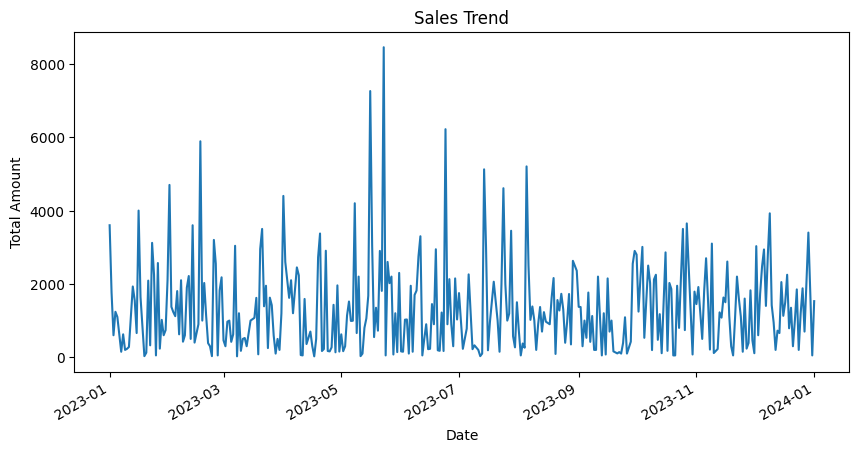

In [14]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Group sales by date
sales = (
    df.groupby('Date')
    ['Total Amount']
    .sum()
)

# Plot
sales.plot(
    figsize=(10,5)
)

plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Amount")

plt.show()

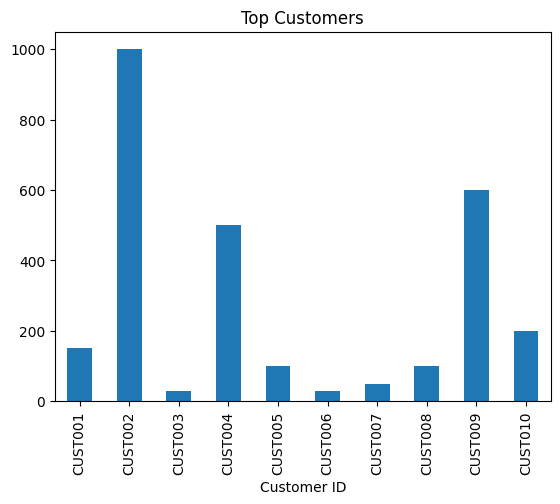

In [15]:
top_customer = (
    df.groupby(
        'Customer ID'
    )['Total Amount']
    .sum()
    .head(10)
)

top_customer.plot(
    kind='bar'
)

plt.title("Top Customers")

plt.show()

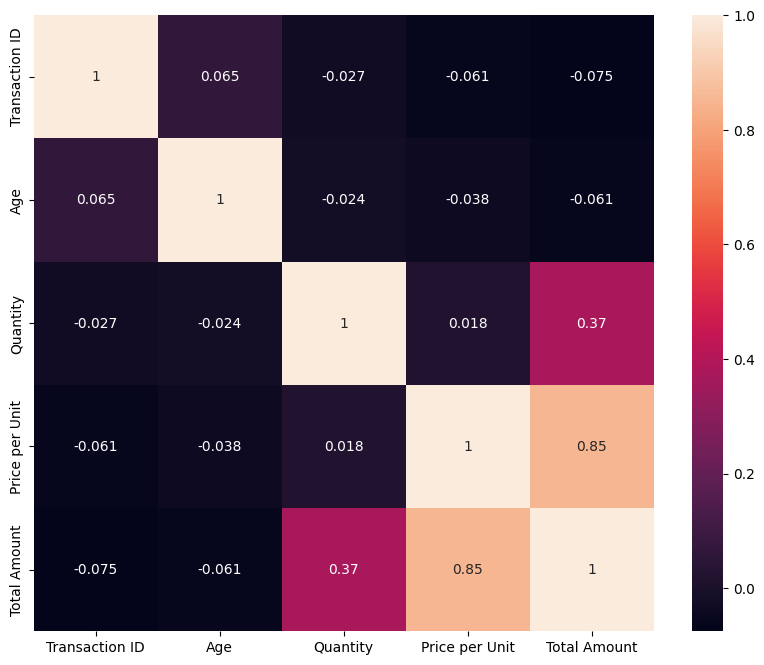

In [16]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True
)

plt.show()

In [20]:
print("""
RECOMMENDATIONS

1. Focus more on top-selling product categories.
2. Improve engagement with low-spending customers.
3. Monitor sales trends regularly.
4. Use customer demographics for targeted marketing.
5. Maintain data quality through periodic cleaning.
""")


RECOMMENDATIONS

1. Focus more on top-selling product categories.
2. Improve engagement with low-spending customers.
3. Monitor sales trends regularly.
4. Use customer demographics for targeted marketing.
5. Maintain data quality through periodic cleaning.

